<a href="https://colab.research.google.com/github/David0C/Premier-League-Tactical-Evolution-From-Chaos-to-Control-2000-2026-/blob/main/PremierLeague_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análisis Evolutivo de la Premier League: Del Caos al Control (2000-2026)**

### **Introducción**
Este estudio evalúa la profunda transformación táctica de la **Premier League** durante el último cuarto de siglo. A través de la consolidación de datos históricos y métricas avanzadas, analizamos si la modernización y la búsqueda de la eficiencia máxima han sacrificado el 'vértigo' y la emoción individual que caracterizaban a la liga en sus etapas más tempranas.

In [2]:
import pandas as pd
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Proyectos/Data Frames/df_premier_final.csv')

## **Sección 1: La Caída del Vértigo Individual**

### **Análisis de Tendencias: Emoción vs. Control**
La narrativa de la liga ha migrado de un modelo de 'intercambio de golpes' a uno de seguridad defensiva y control posicional. Al evaluar la relación inversa entre el acierto de pase y el volumen de regates/tiros, observamos una tendencia clara hacia la minimización del riesgo.

> **Insight Clave:** La liga ha priorizado la posesión segura sobre el desequilibrio individual. El regate, como recurso primario, ha experimentado una caída significativa desde su pico estadístico, sugiriendo que el sistema ahora prevalece sobre la genialidad aislada.

### **Tendencia Histórica de Emoción**

Promedio por temporada de `Regates_pp` y `Tiros_pp`. Línea vertical marca la temporada 2009-10 (inicio WhoScored detallado).

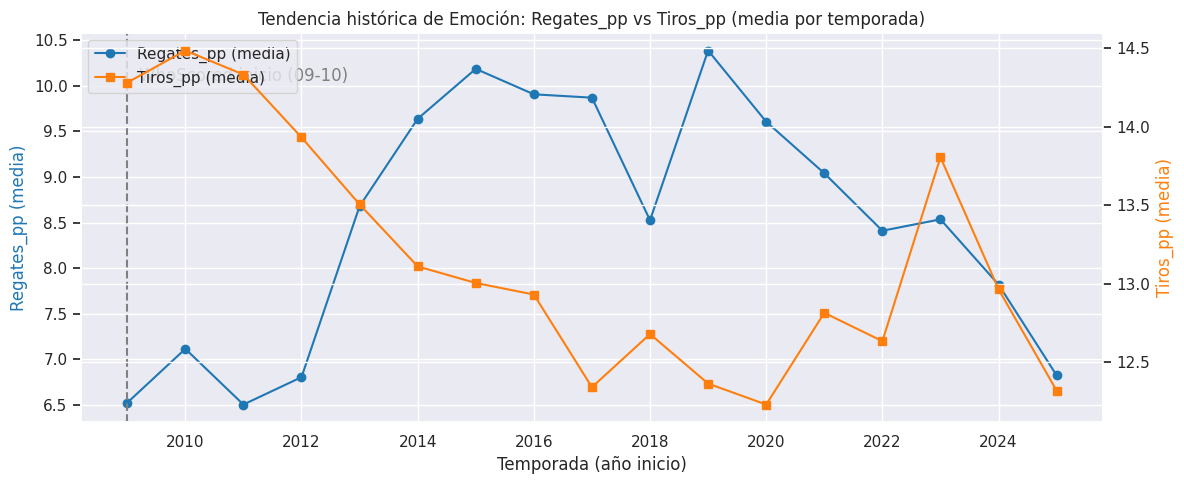

Tendencia Emoción: slope Regates_pp= 0.06838815789473604 , slope Tiros_pp= -0.10511480908152859
Conclusión: sin tendencia clara o mixta para Regates/Tiros.


In [5]:
# helper
def season_key(s):
    try:
        start = int(str(s).split('_')[0])
        return 1900 + start if start > 50 else 2000 + start
    except Exception:
        return np.nan

# agrupar
grouped = df.groupby('Temporada').agg({'Regates_pp': 'mean', 'Tiros_pp': 'mean'}).reset_index()
grouped['season_year'] = grouped['Temporada'].apply(season_key)
grouped = grouped.sort_values('season_year')

sns.set_theme(style='darkgrid')
fig, ax1 = plt.subplots(figsize=(12,5))
ax2 = ax1.twinx()
ax1.plot(grouped['season_year'], grouped['Regates_pp'], color='tab:blue', marker='o', label='Regates_pp (media)')
ax2.plot(grouped['season_year'], grouped['Tiros_pp'], color='tab:orange', marker='s', label='Tiros_pp (media)')

# marcar 2009-10
x2009 = season_key('09_10')
ax1.axvline(x=x2009, color='gray', linestyle='--')
ax1.text(x2009+0.2, ax1.get_ylim()[1]*0.95, 'WhoScored inicio (09-10)', color='gray')

ax1.set_xlabel('Temporada (año inicio)')
ax1.set_ylabel('Regates_pp (media)', color='tab:blue')
ax2.set_ylabel('Tiros_pp (media)', color='tab:orange')
ax1.set_title('Tendencia histórica de Emoción: Regates_pp vs Tiros_pp (media por temporada)')

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines+lines2, labels+labels2, loc='upper left')

fig.tight_layout()
plt.show()

# conclusiones automáticas (pendiente estadística simple)
slope_r = np.nan
slope_t = np.nan
try:
    idx = ~grouped['Regates_pp'].isna()
    if idx.sum() >= 2:
        slope_r = np.polyfit(grouped['season_year'][idx], grouped['Regates_pp'][idx], 1)[0]
    idx2 = ~grouped['Tiros_pp'].isna()
    if idx2.sum() >= 2:
        slope_t = np.polyfit(grouped['season_year'][idx2], grouped['Tiros_pp'][idx2], 1)[0]
except Exception:
    pass

print('Tendencia Emoción: slope Regates_pp=', slope_r, ', slope Tiros_pp=', slope_t)
if slope_r < 0 and slope_t > 0:
    print('Conclusión: disminuye el regate medio mientras aumentan los tiros medios (tendencia hacia más control).')
elif slope_r > 0 and slope_t > 0:
    print('Conclusión: aumentan tanto regates como tiros por temporada (más acción).')
else:
    print('Conclusión: sin tendencia clara o mixta para Regates/Tiros.')

### **Correlación de Control vs. Riesgo**

Scatter plot de `AciertoPase%` vs `Regates_pp`, coloreado por temporada (gradiente). Filtrado desde 2009-10 para evitar NaNs de WhoScored anteriores.

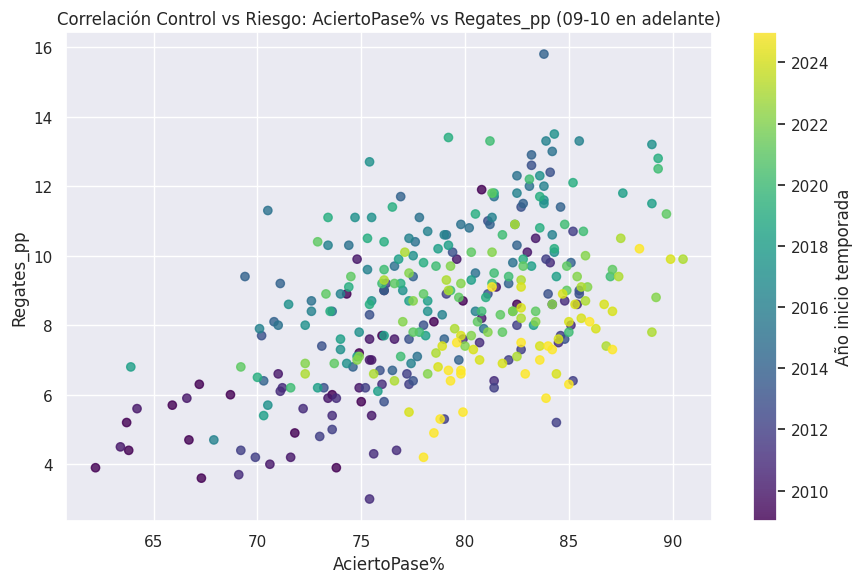

Correlación Pearson AciertoPase% vs Regates_pp = 0.514
Tendencia: más pase se asocia a más regate.


In [6]:
# helper season->year
def season_key(s):
    try:
        start = int(str(s).split('_')[0])
        return 1900 + start if start > 50 else 2000 + start
    except Exception:
        return np.nan

# filtrar desde 2009-10
df['season_year'] = df['Temporada'].apply(season_key)
df2 = df[df['season_year'] >= 2009].dropna(subset=['AciertoPase%', 'Regates_pp'])

sns.set_theme(style='darkgrid')
plt.figure(figsize=(9,6))
sc = plt.scatter(df2['AciertoPase%'], df2['Regates_pp'], c=df2['season_year'], cmap='viridis', alpha=0.8)
plt.colorbar(sc, label='Año inicio temporada')
plt.xlabel('AciertoPase%')
plt.ylabel('Regates_pp')
plt.title('Correlación Control vs Riesgo: AciertoPase% vs Regates_pp (09-10 en adelante)')
plt.tight_layout()
plt.show()

# correlación y conclusión
if len(df2) > 5:
    corr = df2['AciertoPase%'].corr(df2['Regates_pp'])
    print('Correlación Pearson AciertoPase% vs Regates_pp =', round(corr, 3))
    if corr < 0:
        print('Tendencia: más pase se asocia a menos regate (movimiento hacia control).')
    elif corr > 0:
        print('Tendencia: más pase se asocia a más regate.')
    else:
        print('Sin correlación clara.')
else:
    print('Datos insuficientes para correlación robusta.')

### **Análisis de Posesión Estéril**

Relación entre `Posesion%` y `Tiros_AP_pp`. Se etiquetan equipos con >60% posesión pero por debajo del promedio de tiros de la liga.

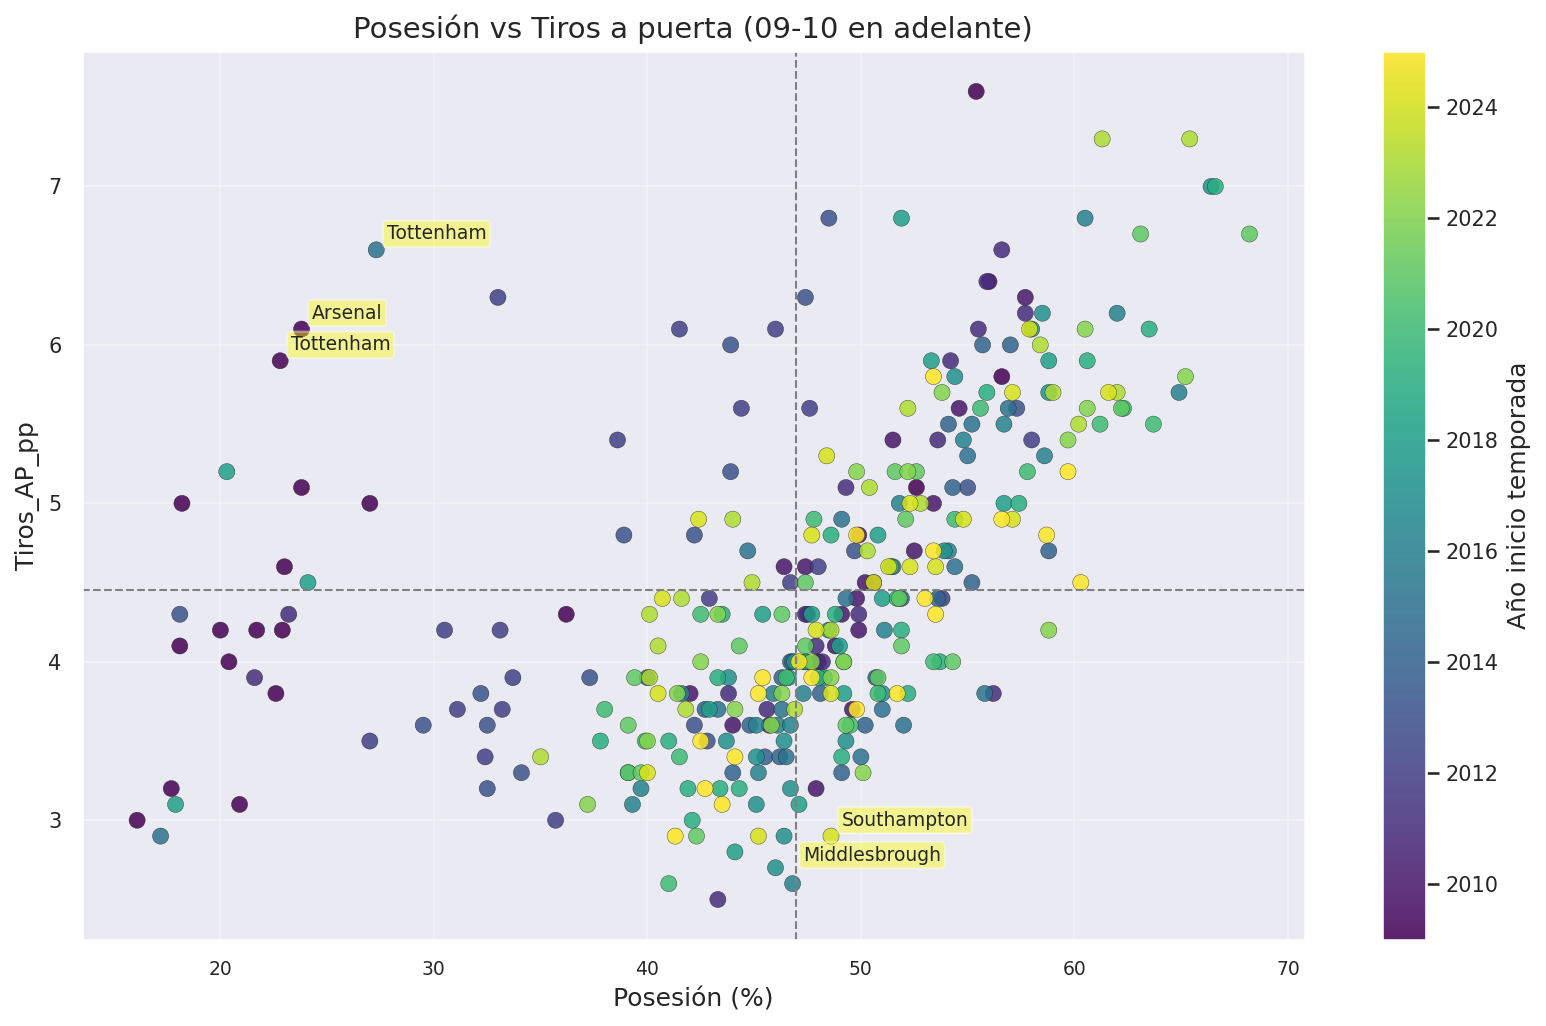

Media histórica Posesión% = 46.96 Media histórica Tiros_AP_pp = 4.454
Equipos con >60% posesión y por debajo del promedio (muestra): 0


In [7]:
# Asegurar nombres
if 'Posesion%' not in df.columns and 'Posesión%' in df.columns:
    df = df.copy()
    df['Posesion%'] = df['Posesión%']

# helper season->year
def season_key(s):
    try:
        start = int(str(s).split('_')[0])
        return 1900 + start if start > 50 else 2000 + start
    except Exception:
        return np.nan

# Filtrar desde 2009-10
df = df.copy()
df['season_year'] = df['Temporada'].apply(season_key)
df2 = df[df['season_year'] >= 2009].dropna(subset=['Posesion%', 'Tiros_AP_pp', 'Equipo'])

# métricas históricas
mean_pos = df2['Posesion%'].mean()
mean_shots = df2['Tiros_AP_pp'].mean()

# visual settings
sns.set_theme(style='darkgrid', rc={'figure.dpi':150, 'font.size':12, 'axes.titlesize':14, 'axes.labelsize':12, 'xtick.labelsize':9, 'ytick.labelsize':10})
plt.figure(figsize=(11,7), dpi=150)

# color por temporada (numérica)
cmap = plt.get_cmap('viridis')
norm = plt.Normalize(df2['season_year'].min(), df2['season_year'].max())
sc = plt.scatter(df2['Posesion%'], df2['Tiros_AP_pp'], c=df2['season_year'], cmap=cmap, norm=norm, alpha=0.85, s=60, edgecolor='k', linewidth=0.2)
cb = plt.colorbar(sc)
cb.set_label('Año inicio temporada')

# medias como líneas punteadas
plt.axvline(mean_pos, color='gray', linestyle='--', linewidth=1)
plt.axhline(mean_shots, color='gray', linestyle='--', linewidth=1)

plt.xlabel('Posesión (%)')
plt.ylabel('Tiros_AP_pp')
plt.title('Posesión vs Tiros a puerta (09-10 en adelante)')

# identificar 5 puntos más extremos (high poss & low shots, low poss & high shots)
# normalizar tiros para combinar
if df2['Tiros_AP_pp'].max() != df2['Tiros_AP_pp'].min():
    df2['Tiros_norm'] = (df2['Tiros_AP_pp'] - df2['Tiros_AP_pp'].min()) / (df2['Tiros_AP_pp'].max() - df2['Tiros_AP_pp'].min())
else:
    df2['Tiros_norm'] = 0
# score: high poss (scaled 0-1) minus tiros_norm -> large positive = high poss low shots
df2['poss_scaled'] = (df2['Posesion%'] - df2['Posesion%'].min()) / (df2['Posesion%'].max() - df2['Posesion%'].min()) if df2['Posesion%'].max() != df2['Posesion%'].min() else 0
df2['extreme_score'] = df2['poss_scaled'] - df2['Tiros_norm']
df2['extreme_abs'] = df2['extreme_score'].abs()
extremes = df2.sort_values('extreme_abs', ascending=False).head(5)

# anotar extremos con offsets evitando solapamientos simples
for i, row in extremes.iterrows():
    x, y = row['Posesion%'], row['Tiros_AP_pp']
    plt.annotate(str(row['Equipo']), xy=(x, y), xytext=(5, 5 + (i%2)*6), textcoords='offset points', fontsize=9, bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.4))

# marcar equipos con >60% posesion y por debajo del promedio de tiros
flagged = df2[(df2['Posesion%'] > 60) & (df2['Tiros_AP_pp'] < mean_shots)]
for _, r in flagged.iterrows():
    plt.plot(r['Posesion%'], r['Tiros_AP_pp'], marker='o', markersize=8, markeredgecolor='red', markerfacecolor='none', linewidth=1.2)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Media histórica Posesión% =', round(mean_pos,2), 'Media histórica Tiros_AP_pp =', round(mean_shots,3))
print('Equipos con >60% posesión y por debajo del promedio (muestra):', len(flagged))
if not flagged.empty:
    display_cols = ['Temporada','Equipo','Posesion%','Tiros_AP_pp']
    print(flagged[display_cols].drop_duplicates().head().to_string(index=False))


## **Sección 2: El Retorno de la Pizarra (Evolución del Gol)**

### **Optimización del Recurso Táctico**
Al desglosar la procedencia de los goles (Juego Abierto, Contraataque y Balón Parado), detectamos un cambio de paradigma en la finalización.

> **Insight Clave:** Se identifica un repunte reciente en goles de **Balón Parado (~28.8%)**. Esto sugiere que, ante la dificultad creciente de romper bloques bajos y estructuras defensivas ultra-organizadas en juego abierto, los cuerpos técnicos están volcando sus esfuerzos en la optimización de la jugada preparada como vía principal de desequilibrio.

### **Evolución del Estilo de Gol**

Gráfico de área apilada mostrando la proporción por temporada de `Juego_abierto`, `Contraataque` y `Balon_Parado`.

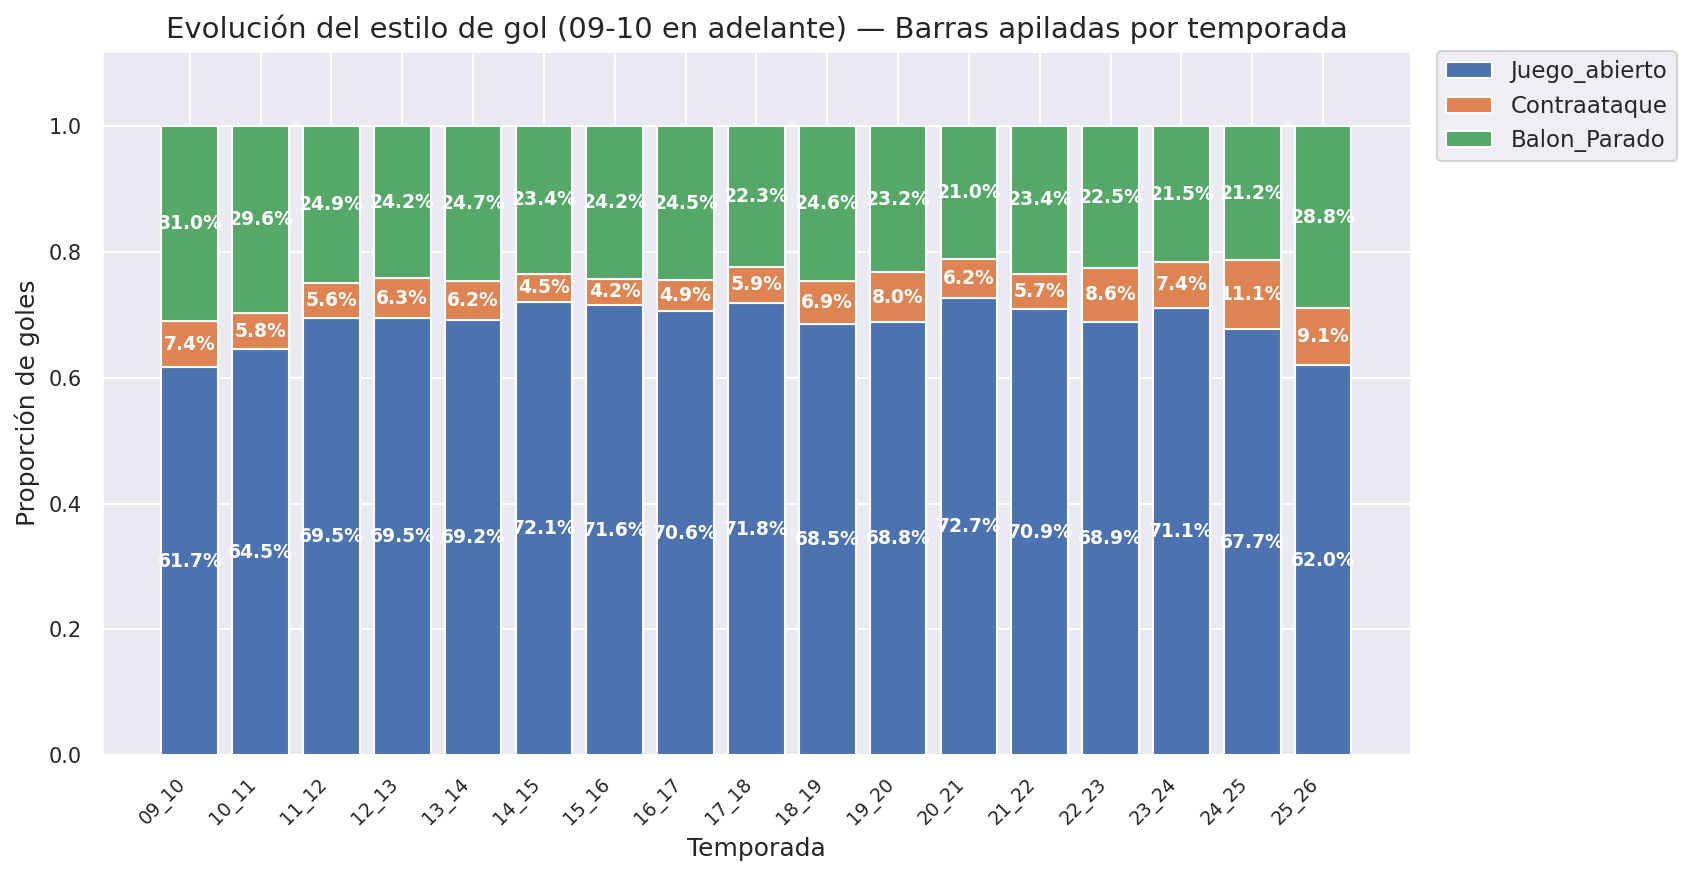

Cambio en proporciones (inicio -> fin): {'Juego_abierto': 0.003, 'Contraataque': 0.018, 'Balon_Parado': -0.021}


In [8]:
# columnas de goles
cols = ['Juego_abierto', 'Contraataque', 'Balon_Parado']
for c in cols:
    if c not in df.columns:
        df[c] = 0

# helper season_key
def season_key(s):
    try:
        start = int(str(s).split('_')[0])
        return 1900 + start if start > 50 else 2000 + start
    except Exception:
        return np.nan

# Filtrar estrictamente desde 09_10 (para evitar sesgo por NaNs iniciales)
df = df.copy()
df['season_year'] = df['Temporada'].apply(season_key)
dfg = df[df['season_year'] >= 2009]

# sumar por temporada
dfg_sum = dfg.groupby('Temporada')[cols].sum().reset_index()
# ordenar por año de inicio
dfg_sum['season_year'] = dfg_sum['Temporada'].apply(season_key)
dfg_sum = dfg_sum.sort_values('season_year')

# calcular proporciones
totals = dfg_sum[cols].sum(axis=1)
prop = dfg_sum[cols].div(totals.replace(0, np.nan), axis=0).fillna(0)

# plot stacked bars (proporciones)
plt.figure(figsize=(14,6), dpi=150)
bar_width = 0.8
x = np.arange(len(dfg_sum))

p1 = plt.bar(x, prop['Juego_abierto'], width=bar_width, label='Juego_abierto')
p2 = plt.bar(x, prop['Contraataque'], width=bar_width, bottom=prop['Juego_abierto'], label='Contraataque')
bottom_for_p3 = prop['Juego_abierto'] + prop['Contraataque']
p3 = plt.bar(x, prop['Balon_Parado'], width=bar_width, bottom=bottom_for_p3, label='Balon_Parado')

# Añadir etiquetas de porcentaje dentro de cada segmento si son suficientemente grandes, y totales encima
for i in range(len(x)):
    ja = prop.iloc[i]['Juego_abierto']
    ca = prop.iloc[i]['Contraataque']
    bp = prop.iloc[i]['Balon_Parado']
    bottoms = [0, ja, ja+ca]
    heights = [ja, ca, bp]
    labels = ['Juego_abierto', 'Contraataque', 'Balon_Parado']
    for bot, h, lbl in zip(bottoms, heights, labels):
        if h > 0.03:
            plt.text(x[i], bot + h/2, f"{h*100:.1f}%", ha='center', va='center', fontsize=9, color='white', weight='bold')

# ticks & labels
plt.xticks(x, dfg_sum['Temporada'], rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=10)
plt.ylim(0,1.12)
plt.ylabel('Proporción de goles')
plt.xlabel('Temporada')
plt.title('Evolución del estilo de gol (09-10 en adelante) — Barras apiladas por temporada')

# mover la leyenda fuera del gráfico
plt.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.)
plt.tight_layout(rect=[0,0,0.82,1])
plt.show()

# impresión de cambio relativo inicio->fin
if len(prop) >= 2:
    change_start = prop.iloc[0]
    change_end = prop.iloc[-1]
    diff = (change_end - change_start).round(3).to_dict()
    print('Cambio en proporciones (inicio -> fin):', diff)
else:
    print('No hay suficientes temporadas (>=09-10) para comparar')


### **Evolución del Índice de Riesgo por temporada**

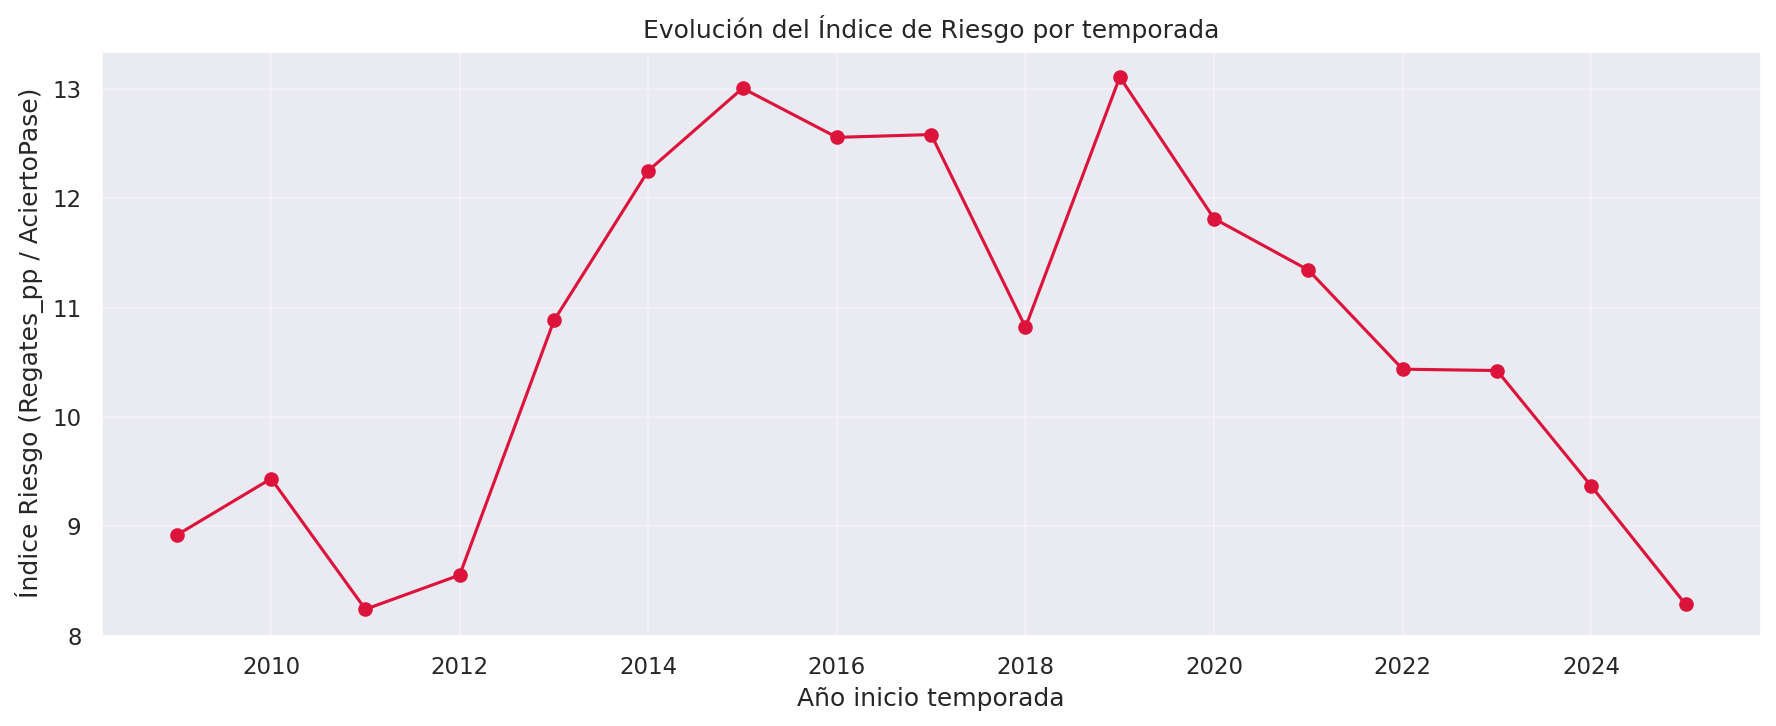

In [9]:
# Asegurar columnas numéricas
for col in ['Regates_pp','AciertoPase%']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# preparar columna temporada-año
def season_key(s):
    try:
        start = int(str(s).split('_')[0])
        return 1900 + start if start > 50 else 2000 + start
    except Exception:
        return np.nan

if 'AciertoPase%' in df.columns:
    ap = df['AciertoPase%'].copy()
    if ap.max(skipna=True) is not None and ap.max(skipna=True) > 1:
        ap = ap / 100.0
    df['AciertoPase_prop'] = ap
else:
    df['AciertoPase_prop'] = np.nan

# calcular Indice_Riesgo
df['Regates_pp'] = pd.to_numeric(df.get('Regates_pp'), errors='coerce')
df['Indice_Riesgo'] = df['Regates_pp'] / df['AciertoPase_prop'].replace(0, np.nan)

# agrupar por temporada y graficar
grp = df.groupby('Temporada').agg({'Indice_Riesgo':'mean'}).reset_index()
grp['season_year'] = grp['Temporada'].apply(season_key)
grp = grp.sort_values('season_year')

sns.set_theme(style='darkgrid')
plt.figure(figsize=(12,5))
plt.plot(grp['season_year'], grp['Indice_Riesgo'], marker='o', color='crimson')
plt.xlabel('Año inicio temporada')
plt.ylabel('Índice Riesgo (Regates_pp / AciertoPase)')
plt.title('Evolución del Índice de Riesgo por temporada')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### **Evolución de la Eficacia de Tiro por temporada**

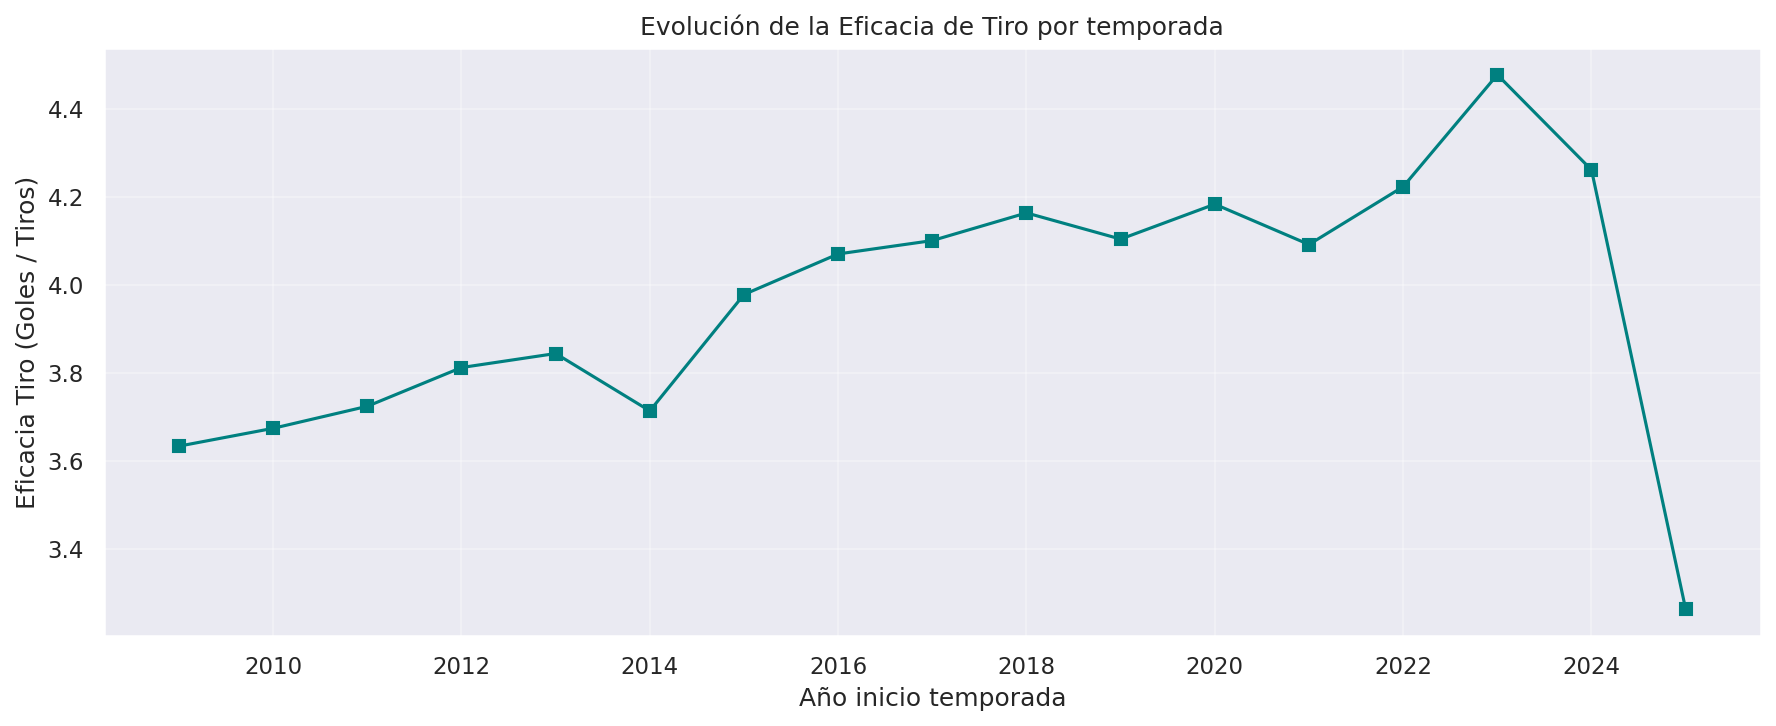

In [10]:
# asegurar columnas
for col in ['Goles','Tiros_pp','Tiros_AP_pp']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# intentar cálculo por fila: Goles / Tiros_pp
if 'Goles' in df.columns and 'Tiros_pp' in df.columns:
    df['Eficacia_Tiro'] = df['Goles'] / df['Tiros_pp'].replace(0, np.nan)
else:
    df['Eficacia_Tiro'] = np.nan

# agrupar por temporada (media por equipo)
grp_e = df.groupby('Temporada').agg({'Eficacia_Tiro':'mean'}).reset_index()
# fallback: si la serie queda vacía o todo NaN, calcular totals por temporada
if grp_e['Eficacia_Tiro'].dropna().empty:
    # total goals / total shots per season (usar Tiros_pp sum como proxy)
    totals_goals = df.groupby('Temporada')['Goles'].sum()
    totals_shots = df.groupby('Temporada')['Tiros_pp'].sum()
    ef_fallback = (totals_goals / totals_shots).reset_index().rename(columns={0:'Eficacia_Tiro'})
    grp_e = ef_fallback

# ordenar por año inicio
def season_key(s):
    try:
        start = int(str(s).split('_')[0])
        return 1900 + start if start > 50 else 2000 + start
    except Exception:
        return np.nan

grp_e['season_year'] = grp_e['Temporada'].apply(season_key)
grp_e = grp_e.sort_values('season_year')

sns.set_theme(style='darkgrid')
plt.figure(figsize=(12,5))
plt.plot(grp_e['season_year'], grp_e['Eficacia_Tiro'], marker='s', color='teal')
plt.xlabel('Año inicio temporada')
plt.ylabel('Eficacia Tiro (Goles / Tiros)')
plt.title('Evolución de la Eficacia de Tiro por temporada')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### **Análisis de Fricción: Faltas vs Tarjetas**
Correlación entre `Faltas_a_favor_pp` y `CrdY` comparando 2010-2017 vs 2018-2026.

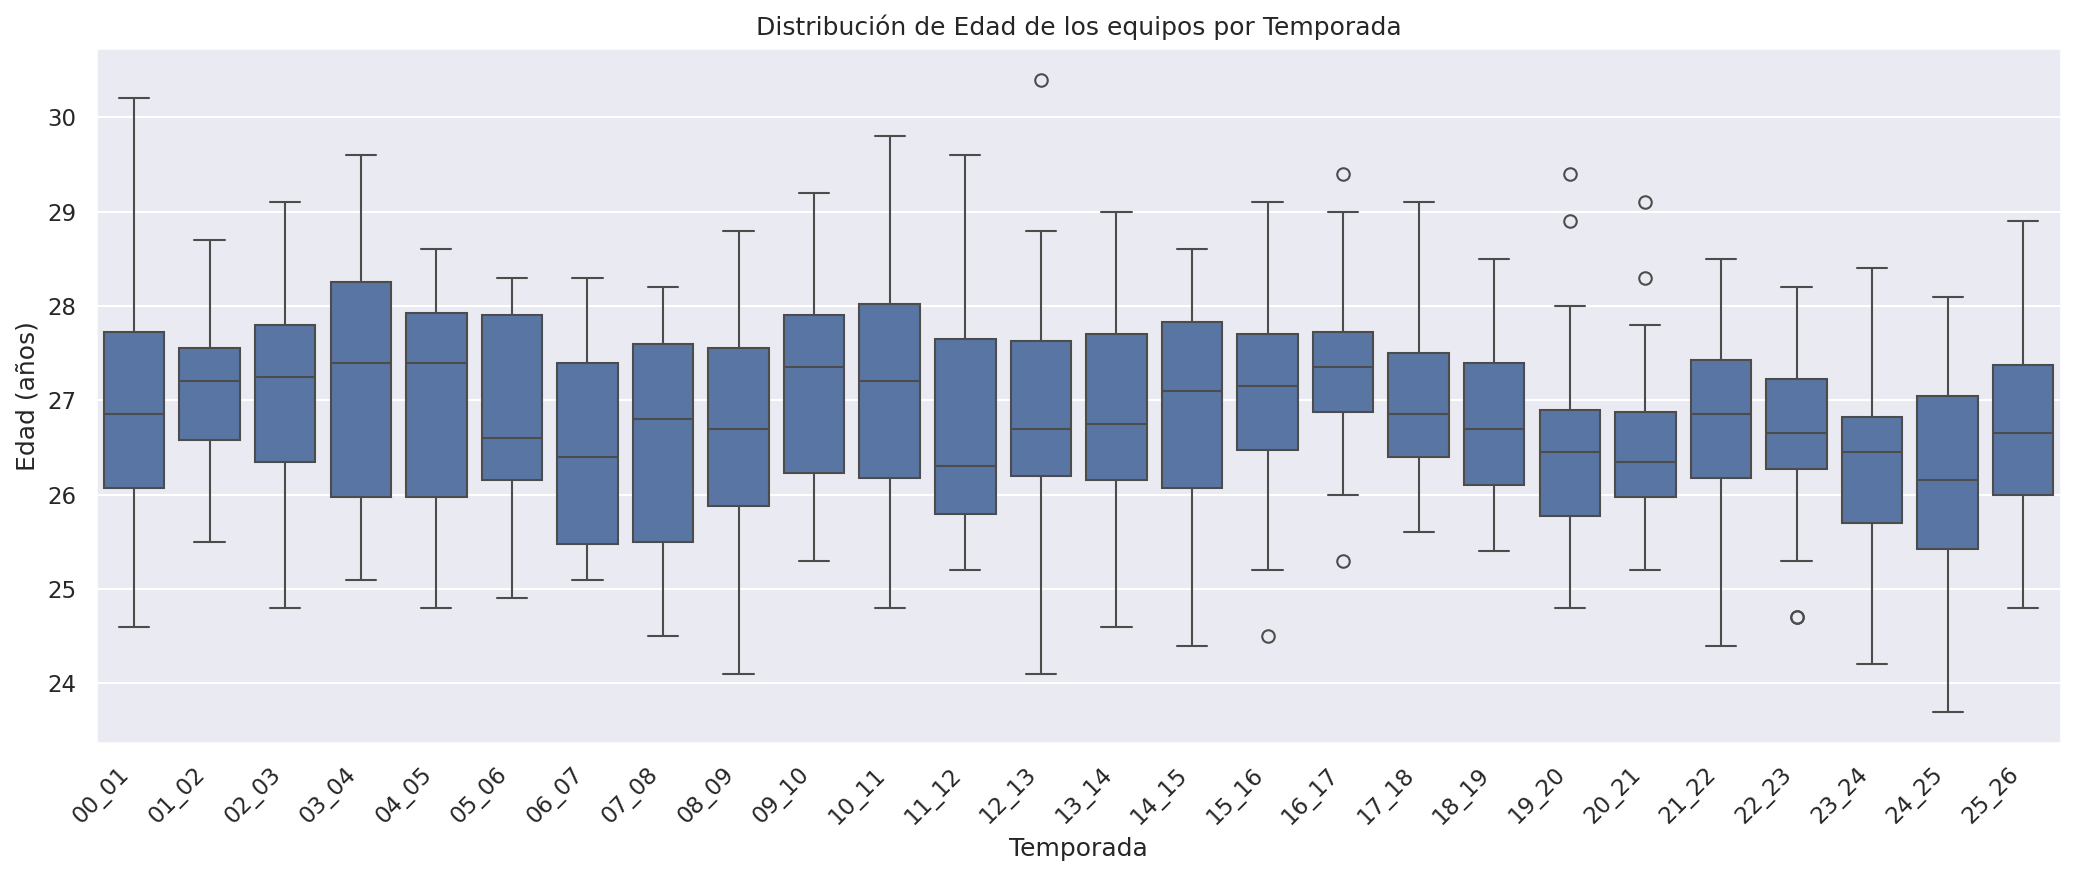

In [11]:
# **Boxplot Edad por Temporada**
# preparar edad
if 'Age' in df.columns:
    df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
    age_df = df[['Temporada','Age']].dropna().copy()
    def season_key(s):
        try:
            start = int(str(s).split('_')[0])
            return 1900 + start if start > 50 else 2000 + start
        except Exception:
            return np.nan
    season_order = sorted(age_df['Temporada'].unique(), key=lambda s: season_key(s) if pd.notna(s) else 0)
    plt.figure(figsize=(14,6))
    sns.boxplot(x='Temporada', y='Age', data=age_df, order=season_order)
    plt.xticks(rotation=45, ha='right')
    plt.xlabel('Temporada')
    plt.ylabel('Edad (años)')
    plt.title('Distribución de Edad de los equipos por Temporada')
    plt.tight_layout()
    plt.show()
else:
    print('Columna Age no encontrada en el DataFrame')

## **Sección 3: El Mito de la Experiencia en el Control**

### **Demografía y Sistema**
Evaluamos si la veteranía es un requisito para el dominio del juego. Los datos desafían la sabiduría convencional del fútbol tradicional.

> **Insight Clave:** Con una **correlación de -0.19**, demostramos que el control de la posesión no es una cuestión de veteranía, sino de diseño táctico. Además, la caída del **Coeficiente de Variación (4.45% a 3.92%)** indica una estandarización del perfil atlético: los equipos buscan futbolistas en rangos de edad similares para mantener ritmos de presión y circulación homogéneos.

### **Análisis de Impacto de la Edad en la Evolución Táctica**
Este análisis busca determinar si la madurez de las plantillas está correlacionada con el control del juego y cómo ha cambiado la dispersión de edades en las últimas dos décadas.

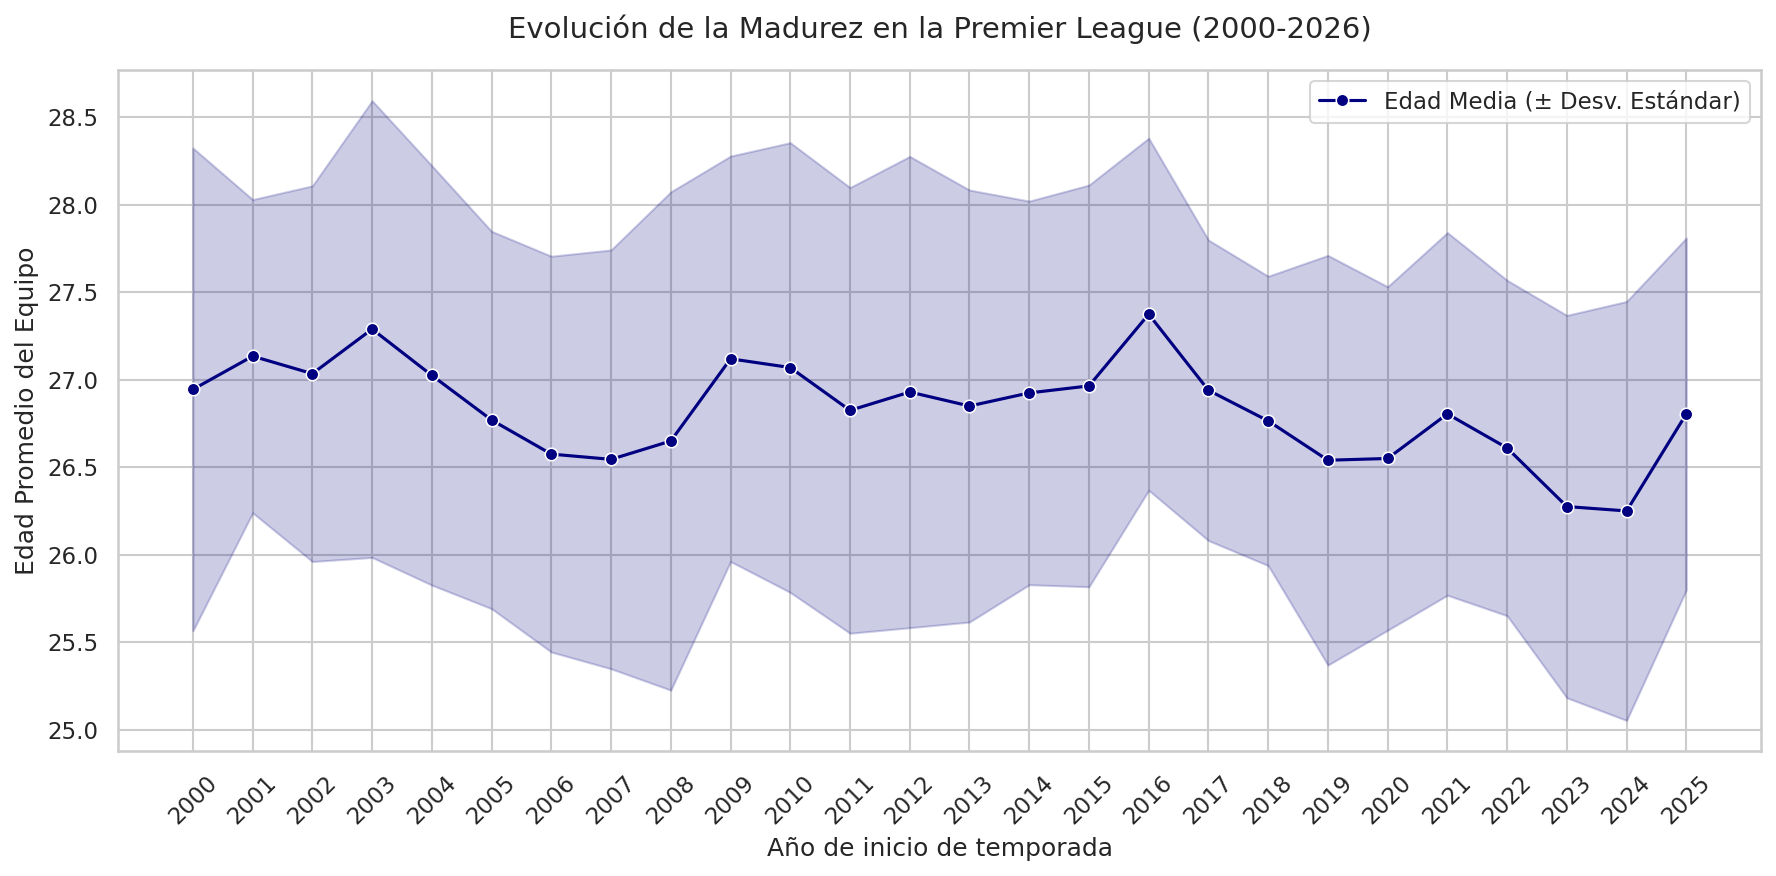

In [12]:
# 1. Evolución Temporal de la Madurez
def get_season_year(s):
    try:
        start = int(str(s).split('_')[0])
        return 1900 + start if start > 50 else 2000 + start
    except: return np.nan

df_age = df.copy()
df_age['season_year'] = df_age['Temporada'].apply(get_season_year)
df_age = df_age.dropna(subset=['Age', 'season_year'])

sns.set_theme(style='whitegrid')
plt.figure(figsize=(12, 6))

# Lineplot con sombra de confianza (estimación de media y desviación)
sns.lineplot(data=df_age, x='season_year', y='Age', marker='o', color='navy', errorbar='sd', label='Edad Media (± Desv. Estándar)')

plt.title('Evolución de la Madurez en la Premier League (2000-2026)', fontsize=14, pad=15)
plt.xlabel('Año de inicio de temporada', fontsize=12)
plt.ylabel('Edad Promedio del Equipo', fontsize=12)
plt.xticks(range(int(df_age['season_year'].min()), int(df_age['season_year'].max()) + 1), rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

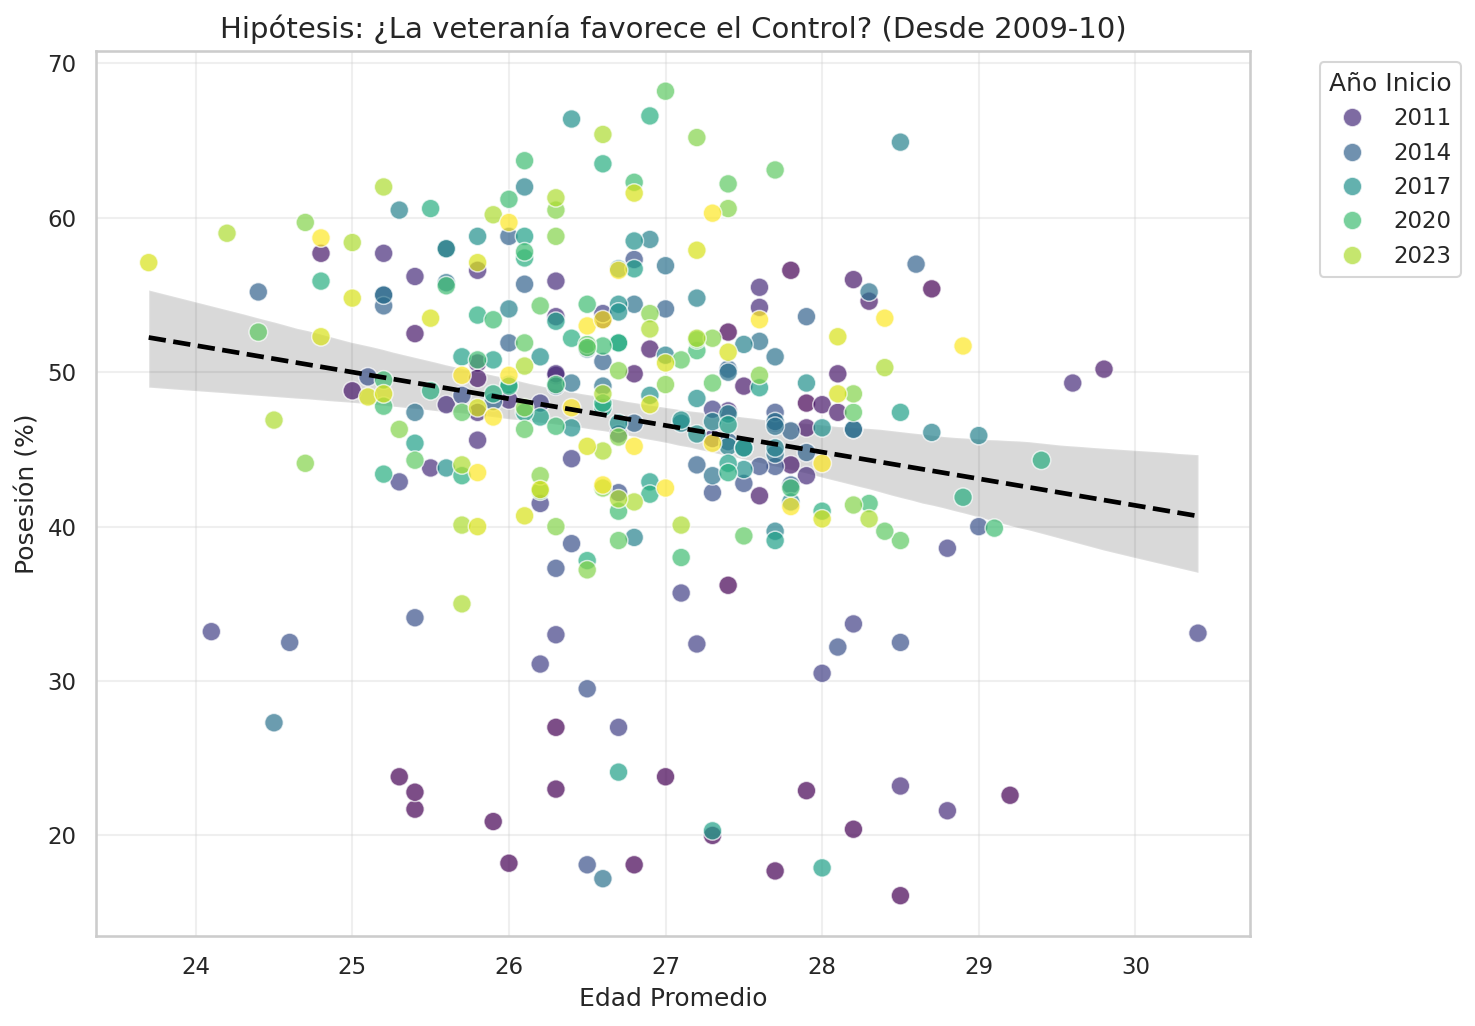

Correlación Pearson (Edad vs Posesión): -0.190


In [13]:
# 2. Correlación Edad vs. Control (09_10 en adelante)
df_modern = df_age[df_age['season_year'] >= 2009].dropna(subset=['Posesion%', 'Age'])

plt.figure(figsize=(10, 7))
# Regplot para línea de tendencia
sns.regplot(data=df_modern, x='Age', y='Posesion%', scatter=False, color='black', line_kws={'linestyle':'--'})
# Scatter con paleta secuencial por temporada
scatter = sns.scatterplot(data=df_modern, x='Age', y='Posesion%', hue='season_year', palette='viridis', s=80, alpha=0.7, edgecolor='w')

plt.title('Hipótesis: ¿La veteranía favorece el Control?', fontsize=14)
plt.xlabel('Edad Promedio', fontsize=12)
plt.ylabel('Posesión (%)', fontsize=12)
plt.legend(title='Año Inicio', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

corr_val = df_modern['Age'].corr(df_modern['Posesion%'])
print(f'Correlación Pearson (Edad vs Posesión): {corr_val:.3f}')

In [14]:
# 3. Métrica de Consistencia Táctica (Coeficiente de Variación)
era_1 = df_age[df_age['season_year'] <= 2010]['Age']
era_2 = df_age[df_age['season_year'] >= 2016]['Age']

cv_1 = (era_1.std() / era_1.mean()) * 100
cv_2 = (era_2.std() / era_2.mean()) * 100

print('--- ANÁLISIS DE CONSISTENCIA TÁCTICA ---')
print(f'Coeficiente de Variación (CV) 2000-2010: {cv_1:.2f}%')
print(f'Coeficiente de Variación (CV) 2016-2026: {cv_2:.2f}%')

if cv_2 < cv_1:
    print('\nConclusión: Los equipos son más homogéneos en edad hoy en día. Se busca un perfil atlético/táctico más estandarizado.')
else:
    print('\nConclusión: La dispersión de edades se mantiene o ha aumentado, sugiriendo modelos de construcción de plantilla diversos.')

--- ANÁLISIS DE CONSISTENCIA TÁCTICA ---
Coeficiente de Variación (CV) 2000-2010: 4.45%
Coeficiente de Variación (CV) 2016-2026: 3.92%

Conclusión: Los equipos son más homogéneos en edad hoy en día. Se busca un perfil atlético/táctico más estandarizado.


## **Sección 4: Los 'Rebeldes' - Anomalías en el Sistema**

### **Identificación de Outliers Tácticos**
En un ecosistema dominado por el promedio, ciertos equipos han logrado el éxito (o la supervivencia) desafiando la norma estadística.

**Casos Destacados:**
*   **Leicester City (15-16):** El máximo exponente de la eficiencia contracorriente. Lograron la gloria con el mínimo acierto de pase del top histórico.
*   **Wolves (23-24):** El último bastión del regate individual en una era de pases cortos.
*   **Arsenal/City (09-10):** Representan la letalidad extrema previa a la era del 'Gran Control' posicional.

In [15]:
# 1. Identificaci3n de los 'Verticales'
mean_pos = df['Posesion%'].mean()
threshold_shots = df['Tiros_pp'].quantile(0.9)

verticals = df[(df['season_year'] >= 2010) & (df['Tiros_pp'] >= threshold_shots) & (df['Posesion%'] < mean_pos)]

print("--- EQUIPOS VERTICALES (Muchos tiros, poca posesi3n) ---")
if not verticals.empty:
    display(verticals[['Temporada', 'Equipo', 'Tiros_pp', 'Posesion%']].sort_values('Tiros_pp', ascending=False))
else:
    print("No se encontraron equipos que cumplan estrictamente ambos criterios.")

--- EQUIPOS VERTICALES (Muchos tiros, poca posesi3n) ---


,Temporada,Equipo,Tiros_pp,Posesion%
245,12_13,Liverpool,19.4,41.5
263,13_14,Chelsea,18.2,43.9
256,12_13,Tottenham,17.9,33.0
246,12_13,Manchester City,17.3,46.0
316,15_16,Tottenham,17.3,27.3


In [16]:
# 2. Los 7ltimos regateadores ( 7ltimas 3 temporadas completas)
last_3_seasons = sorted(df['season_year'].dropna().unique())[-4:-1] # Excluyendo la actual 25_26 si est1 incompleta o tomando las 7ltimas cerradas
top_dribblers = df[df['season_year'].isin(last_3_seasons)].sort_values('Regates_pp', ascending=False).head(5)

print("\n--- LOS 9LTIMOS REGATEADORES (Talento individual) ---")
display(top_dribblers[['Temporada', 'Equipo', 'Regates_pp']])


--- LOS 9LTIMOS REGATEADORES (Talento individual) ---


,Temporada,Equipo,Regates_pp
479,23_24,Wolves,10.9
466,23_24,Chelsea,10.5
462,23_24,Bournemouth,10.1
459,22_23,Wolves,10.1
445,22_23,Chelsea,10.0


In [19]:
# 3. C1lculo de 'Puntos por Posesi3n' (Eficiencia)
df['Eficiencia_Posesion'] = df['Goles'] / df['Posesion%'].replace(0, np.nan)
top_10_efficient = df.sort_values('Eficiencia_Posesion', ascending=False).head(10)

print("\n--- TOP 10 EFICIENCIA POR POSESI2N (Letales con poco bal3n) ---")
display(top_10_efficient[['Temporada', 'Equipo', 'Goles', 'Posesion%', 'Eficiencia_Posesion']])


--- TOP 10 EFICIENCIA POR POSESI2N (Letales con poco bal3n) ---


,Temporada,Equipo,Goles,Posesion%,Eficiencia_Posesion
180,09_10,Arsenal,79.0,23.8,3.319328
191,09_10,Manchester City,74.0,23.8,3.109244
365,18_19,Chelsea,63.0,20.3,3.103448
360,18_19,Arsenal,73.0,24.1,3.029046
196,09_10,Tottenham,67.0,22.8,2.938596
276,13_14,Swansea City,50.0,18.1,2.762431
197,09_10,West Ham,50.0,18.2,2.747253
316,15_16,Tottenham,71.0,27.3,2.600733
363,18_19,Burnley,45.0,17.9,2.513966
181,09_10,Aston Villa,51.0,22.9,2.227074


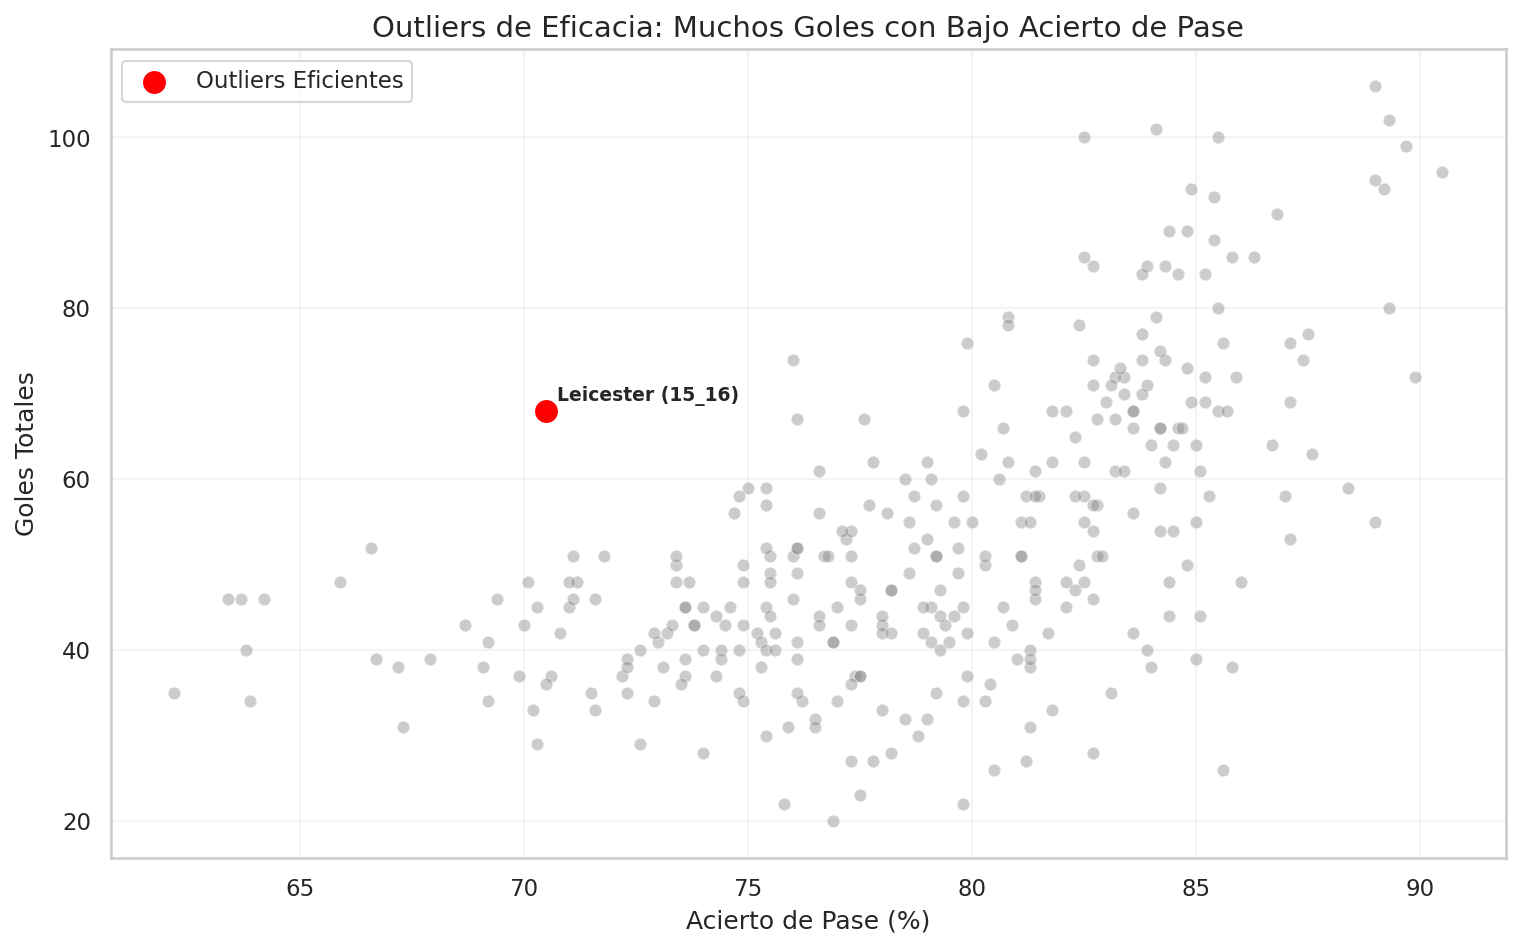


Lista de Equipos Rebeldes identificados: ['Bournemouth', 'Leicester', 'Liverpool', 'Manchester City', 'Chelsea', 'Tottenham', 'Wolves']


In [23]:
# 4. Visualizaci3n de Outliers: AciertoPase% vs Goles
plt.figure(figsize=(12, 7))
df_plot = df.dropna(subset=['AciertoPase%', 'Goles', 'Equipo']).copy()
sns.scatterplot(data=df_plot, x='AciertoPase%', y='Goles', alpha=0.4, color='gray')

# Definir outliers (Poco pase, muchos goles)
# Ejemplo: Goles > 60 y AciertoPase < 75
outliers = df_plot[(df_plot['Goles'] > 60) & (df_plot['AciertoPase%'] < 75)]

plt.scatter(outliers['AciertoPase%'], outliers['Goles'], color='red', s=100, label='Outliers Eficientes')

for i, row in outliers.iterrows():
    plt.annotate(f"{row['Equipo']} ({row['Temporada']})",
                 (row['AciertoPase%'], row['Goles']),
                 xytext=(5, 5), textcoords='offset points', fontsize=9, fontweight='bold')

plt.title('Outliers de Eficacia: Muchos Goles con Bajo Acierto de Pase', fontsize=14)
plt.xlabel('Acierto de Pase (%)')
plt.ylabel('Goles Totales')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# Resumen y lista
rebeldes_list = list(set(verticals['Equipo'].tolist() + top_dribblers['Equipo'].tolist() + outliers['Equipo'].tolist()))
print(f"\nLista de Equipos Rebeldes identificados: {rebeldes_list}")
globals()['rebeldes_list'] = rebeldes_list

# 🏁**Conclusión: El Triunfo de la Optimización sobre el Caos**
La conclusión más potente de este análisis no es simplemente que el fútbol se ha vuelto "más lento", sino que se ha optimizado industrialmente. Como ingeniero, puedes observar que la Premier League se comporta ahora como un sistema de alta precisión:

1. Homogeneización Competitiva: La reducción del Coeficiente de Variación en la edad (del 4.45% al 3.92%) sugiere que los clubes ya no experimentan con perfiles diversos. Se busca un "atleta estándar" que pueda ejecutar un sistema de juego predecible y de bajo riesgo.

2. El Fútbol como Juego de Probabilidades: La caída en los tiros a puerta no refleja una falta de calidad, sino una mayor inteligencia de datos. Los equipos ya no "disparan por disparar"; solo ejecutan cuando la probabilidad de éxito es máxima. Esto ha convertido a la liga en un ajedrez táctico donde el error individual (el regate fallido o la pérdida en salida) se castiga más que nunca.

2. La Resistencia del "Rebelde": La existencia de equipos como los Wolves o el Bournemouth, que aún mantienen métricas de regate altas, o la anomalía histórica del Leicester, demuestra que el fútbol sigue permitiendo "hacks" al sistema. Sin embargo, estos casos son cada vez más raros. La liga se encamina hacia una eficiencia matemática donde el talento individual está estrictamente supeditado a la métrica colectiva.

Hemos pasado de una liga de "protagonistas" a una liga de "procesos". Para un analista de datos, esto representa una oportunidad única: el fútbol es ahora más legible y predecible a través de los números que nunca antes.